Đang xử lý 100 ảnh với các đặc trưng nâng cao...
Đang chạy Spectral Clustering...

--- KẾT QUẢ SPECTRAL CLUSTERING + ADVANCED FEATURES ---
              precision    recall  f1-score   support

           0       0.70      0.57      0.63        80
           1       0.64      0.75      0.69        80

    accuracy                           0.66       160
   macro avg       0.67      0.66      0.66       160
weighted avg       0.67      0.66      0.66       160

Confusion Matrix:
[[46 34]
 [20 60]]

Độ quan trọng của các đặc trưng:
PathLength     0.269696
HullArea       0.213900
SwitchRate     0.213878
Entropy        0.180656
RevisitRate    0.121870
dtype: float64


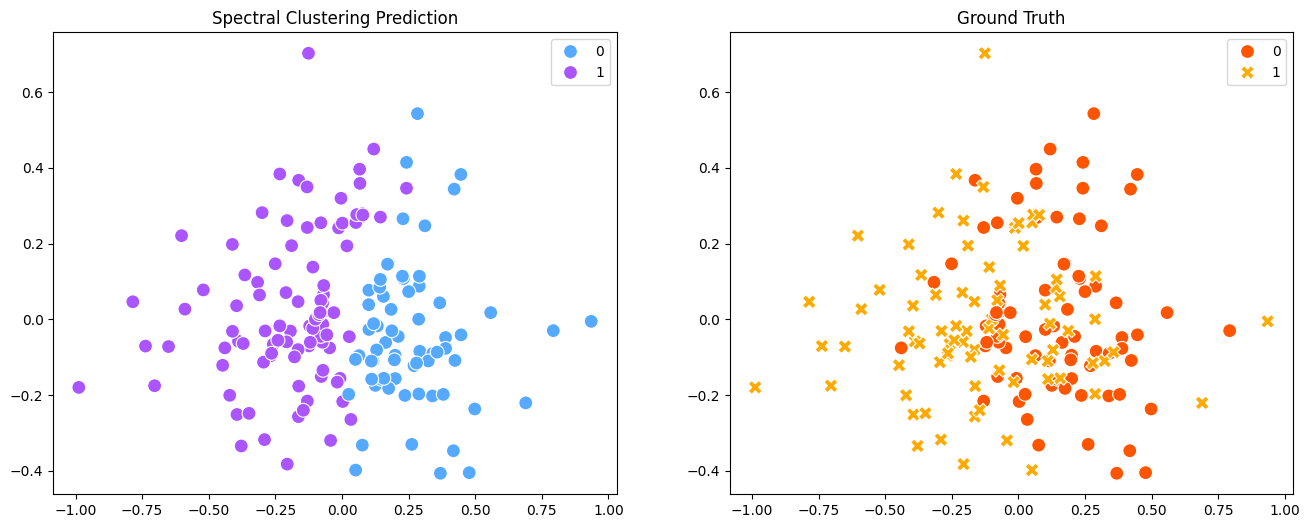

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from scipy.spatial import ConvexHull, QhullError
from scipy.stats import entropy

# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'
df = pd.read_csv(file_path)

# Hàm tính toán đặc trưng nâng cao
def calculate_advanced_behavior(user_data, cluster_centers):
    if len(user_data) < 3: return None # Cần ít nhất 3 điểm để tính Revisit/Hull
    
    # --- A. PHÂN TÍCH VÙNG NHÌN (ROI) ---
    # Dự đoán vùng nhìn (0, 1, 2, 3...)
    rois = cluster_centers.predict(user_data[['FIX_X', 'FIX_Y']])
    
    # 1. Switch Rate (Đã chứng minh là hiệu quả)
    switches = sum(rois[i] != rois[i-1] for i in range(1, len(rois)))
    switch_rate = switches / len(rois)
    
    # 2. Entropy (Độ phân tán sự chú ý)
    val_counts = pd.Series(rois).value_counts(normalize=True)
    ent = entropy(val_counts)
    
    # 3. NEW: Revisit Rate (Tỷ lệ lặp lại - dấu hiệu của trí nhớ kém/check lại)
    # Đếm số lần quay lại vùng vừa bỏ đi (A -> B -> A)
    revisits = 0
    if len(rois) > 2:
        for i in range(2, len(rois)):
            if rois[i] == rois[i-2] and rois[i] != rois[i-1]:
                revisits += 1
    revisit_rate = revisits / len(rois)

    # --- B. PHÂN TÍCH KHÔNG GIAN (GLOBAL) ---
    points = user_data[['FIX_X', 'FIX_Y']].values
    
    # 4. NEW: Convex Hull Area (Diện tích bao phủ)
    # Đo xem mắt quét rộng hay hẹp
    try:
        hull = ConvexHull(points)
        hull_area = hull.volume # Trong 2D, volume chính là diện tích
    except QhullError:
        hull_area = 0 # Nếu các điểm thẳng hàng
        
    # 5. NEW: Scanpath Length (Tổng quãng đường)
    diffs = np.diff(points, axis=0)
    path_len = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    
    # Chuẩn hóa diện tích và đường đi theo kích thước màn hình (để số không quá to)
    hull_norm = hull_area / (1920 * 1080)
    path_norm = path_len / 10000 
    
    return [switch_rate, ent, revisit_rate, hull_norm, path_norm]

# --- MAIN LOOP ---
patient_behaviors = {}
unique_images = df['image_id'].unique()

print(f"Đang xử lý {len(unique_images)} ảnh với các đặc trưng nâng cao...")

for img_id in unique_images:
    img_data = df[df['image_id'] == img_id].copy()
    if len(img_data) < 50: continue 
    
    # 1. Tìm Dynamic ROIs cho ảnh này
    kmeans_roi = KMeans(n_clusters=5, random_state=42, n_init=10)
    kmeans_roi.fit(img_data[['FIX_X', 'FIX_Y']])
    
    # 2. Tính đặc trưng cho từng người
    for pid, group in img_data.groupby('numeric_id'):
        feats = calculate_advanced_behavior(group, kmeans_roi)
        if feats:
            if pid not in patient_behaviors: patient_behaviors[pid] = []
            patient_behaviors[pid].append(feats)

# --- AGGREGATION ---
final_X = []
final_y = []
pids = []

label_map = df.drop_duplicates('numeric_id').set_index('numeric_id')['label']

for pid, feats_list in patient_behaviors.items():
    if not feats_list: continue
    
    # Tính trung bình các chỉ số trên tất cả các ảnh bệnh nhân đã xem
    avg_feats = np.mean(feats_list, axis=0)
    
    final_X.append(avg_feats)
    final_y.append(label_map[pid])
    pids.append(pid)

X = np.array(final_X)
y_true = np.array(final_y)
feat_names = ['SwitchRate', 'Entropy', 'RevisitRate', 'HullArea', 'PathLength']

# --- CLUSTERING: SPECTRAL CLUSTERING ---
# Spectral Clustering hoạt động tốt hơn K-Means khi dữ liệu phức tạp
print("Đang chạy Spectral Clustering...")

# Chuẩn hóa về [0, 1] cho Spectral Clustering
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# affinity='nearest_neighbors': Tạo graph kết nối các điểm giống nhau
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42, n_neighbors=10)
preds = spectral.fit_predict(X_scaled)

# Check đảo nhãn
from sklearn.metrics import accuracy_score, confusion_matrix
if accuracy_score(y_true, preds) < 0.5:
    preds = 1 - preds

# --- REPORT ---
print("\n--- KẾT QUẢ SPECTRAL CLUSTERING + ADVANCED FEATURES ---")
print(classification_report(y_true, preds))
print("Confusion Matrix:")
print(confusion_matrix(y_true, preds))

# --- FEATURE IMPORTANCE (Explainability) ---
# Dùng Random Forest để xem đặc trưng mới (Revisit, Hull) có hiệu quả không
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y_true)
importances = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nĐộ quan trọng của các đặc trưng:")
print(importances)

# --- VISUALIZATION ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=preds, palette='cool', s=100)
plt.title('Spectral Clustering Prediction')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_true, palette='autumn', style=y_true, s=100)
plt.title('Ground Truth')
plt.show()